In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path
import imageio

def load_image_sequence(folder_path):
    """Load all TIFF images from folder"""
    folder = Path(folder_path)
    tif_files = sorted(folder.glob('*.tif')) + sorted(folder.glob('*.tiff'))
    
    images = []
    for file in tif_files[:51]:  # Limit to 51 as specified
        img = tifffile.imread(file)
        images.append(img)
    
    return images, [f.name for f in tif_files[:51]]

def quick_visual_assessment(images, num_samples=5):
    """Display sample images to visually assess misalignment"""
    indices = np.linspace(0, len(images)-1, num_samples, dtype=int)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
    for idx, ax in zip(indices, axes):
        ax.imshow(images[idx], cmap='hot')
        ax.set_title(f'Image {idx}')
        ax.axis('off')
    
    plt.suptitle('Sample Images from Sequence')
    plt.show()




In [5]:
import cv2
from skimage import metrics
import pandas as pd

def analyze_registration_issues(images):
    """Comprehensive analysis of registration requirements"""
    
    results = {
        'image_index': [],
        'translation_x': [],
        'translation_y': [],
        'rotation_angle': [],
        'scale_change': [],
        'ncc_score': [],
        'mse': []
    }
    
    # Use first image as reference
    ref_image = images[0].astype(np.float32)
    
    for i, img in enumerate(images):
        img_float = img.astype(np.float32)
        
        # 1. Detect key features (SIFT/ORB)
        sift = cv2.SIFT_create()
        kp1, des1 = sift.detectAndCompute(ref_image.astype(np.uint8), None)
        kp2, des2 = sift.detectAndCompute(img_float.astype(np.uint8), None)
        
        # 2. Feature matching
        bf = cv2.BFMatcher()
        matches = bf.knnMatch(des1, des2, k=2) if des1 is not None and des2 is not None else []
        
        # 3. Estimate transformation
        if len(matches) > 10:
            good_matches = []
            for m, n in matches:
                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)
            print("good matches: ", len(good_matches))
            if len(good_matches) > 4:
                src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
                dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])
                
                # Estimate affine transformation
                M, mask = cv2.estimateAffinePartial2D(src_pts, dst_pts)
                
                if M is not None:
                    # Extract transformation parameters
                    translation_x = M[0, 2]
                    translation_y = M[1, 2]
                    
                    # Extract rotation and scale
                    a, b = M[0, 0], M[0, 1]
                    scale = np.sqrt(a**2 + b**2)
                    rotation = np.arctan2(b, a) * 180 / np.pi
                else:
                    translation_x = translation_y = rotation = scale = 0
            else:
                translation_x = translation_y = rotation = scale = 0
        else:
            translation_x = translation_y = rotation = scale = 0
        
        # 4. Calculate similarity metrics
        if ref_image.shape == img_float.shape:
            ncc = np.corrcoef(ref_image.flatten(), img_float.flatten())[0, 1]
            mse = np.mean((ref_image - img_float) ** 2)
        else:
            ncc = mse = np.nan
        
        # Store results
        results['image_index'].append(i)
        results['translation_x'].append(translation_x)
        results['translation_y'].append(translation_y)
        results['rotation_angle'].append(rotation)
        results['scale_change'].append(scale)
        results['ncc_score'].append(ncc)
        results['mse'].append(mse)
    
    return pd.DataFrame(results)

def visualize_transformations(df):
    """Visualize the detected transformations"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Translation X
    axes[0, 0].plot(df['image_index'], df['translation_x'], 'bo-')
    axes[0, 0].set_xlabel('Image Index')
    axes[0, 0].set_ylabel('Translation X (pixels)')
    axes[0, 0].set_title('Horizontal Translation')
    axes[0, 0].grid(True)
    
    # Translation Y
    axes[0, 1].plot(df['image_index'], df['translation_y'], 'ro-')
    axes[0, 1].set_xlabel('Image Index')
    axes[0, 1].set_ylabel('Translation Y (pixels)')
    axes[0, 1].set_title('Vertical Translation')
    axes[0, 1].grid(True)
    
    # Rotation
    axes[0, 2].plot(df['image_index'], df['rotation_angle'], 'go-')
    axes[0, 2].set_xlabel('Image Index')
    axes[0, 2].set_ylabel('Rotation Angle (degrees)')
    axes[0, 2].set_title('Rotation')
    axes[0, 2].grid(True)
    
    # Scale
    axes[1, 0].plot(df['image_index'], df['scale_change'], 'mo-')
    axes[1, 0].set_xlabel('Image Index')
    axes[1, 0].set_ylabel('Scale Factor')
    axes[1, 0].set_title('Scale Changes')
    axes[1, 0].grid(True)
    
    # NCC Score
    axes[1, 1].plot(df['image_index'], df['ncc_score'], 'co-')
    axes[1, 1].set_xlabel('Image Index')
    axes[1, 1].set_ylabel('NCC Score')
    axes[1, 1].set_title('Normalized Cross-Correlation')
    axes[1, 1].grid(True)
    
    # MSE
    axes[1, 2].plot(df['image_index'], df['mse'], 'yo-')
    axes[1, 2].set_xlabel('Image Index')
    axes[1, 2].set_ylabel('MSE')
    axes[1, 2].set_title('Mean Squared Error')
    axes[1, 2].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 60)
    print("REGISTRATION ANALYSIS SUMMARY")
    print("=" * 60)
    print(f"Maximum Translation X: {df['translation_x'].abs().max():.2f} pixels")
    print(f"Maximum Translation Y: {df['translation_y'].abs().max():.2f} pixels")
    print(f"Maximum Rotation: {df['rotation_angle'].abs().max():.2f} degrees")
    print(f"Scale Variation: {df['scale_change'].std():.4f} (std dev)")
    print(f"Average NCC: {df['ncc_score'].mean():.4f}")
    print(f"Average MSE: {df['mse'].mean():.2f}")

Loading image sequence...
Loaded 51 images

Performing visual assessment...


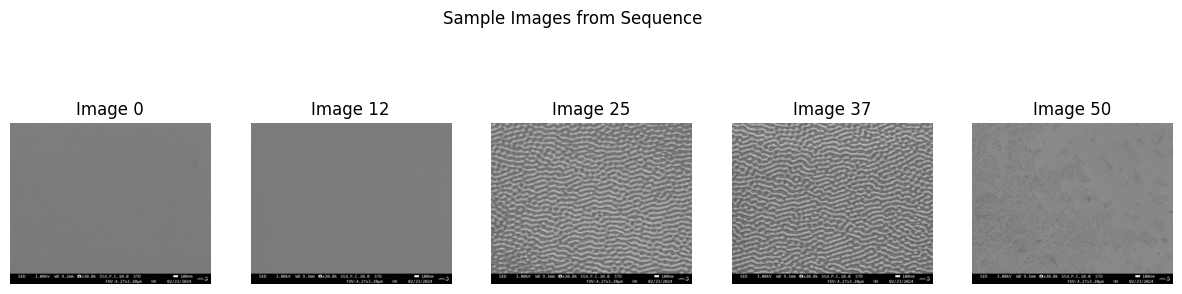


Analyzing registration requirements...
good matches:  974
good matches:  928
good matches:  919
good matches:  928
good matches:  923
good matches:  926
good matches:  915
good matches:  917
good matches:  914
good matches:  916
good matches:  925
good matches:  920
good matches:  926
good matches:  916
good matches:  921
good matches:  919
good matches:  918
good matches:  909
good matches:  913
good matches:  914
good matches:  919
good matches:  907
good matches:  910
good matches:  926
good matches:  908
good matches:  914
good matches:  913
good matches:  915
good matches:  915
good matches:  914
good matches:  904
good matches:  902
good matches:  907
good matches:  907
good matches:  921
good matches:  927
good matches:  913
good matches:  917
good matches:  921
good matches:  908
good matches:  900
good matches:  911
good matches:  898
good matches:  904
good matches:  905
good matches:  919
good matches:  909
good matches:  917
good matches:  921
good matches:  922
good match

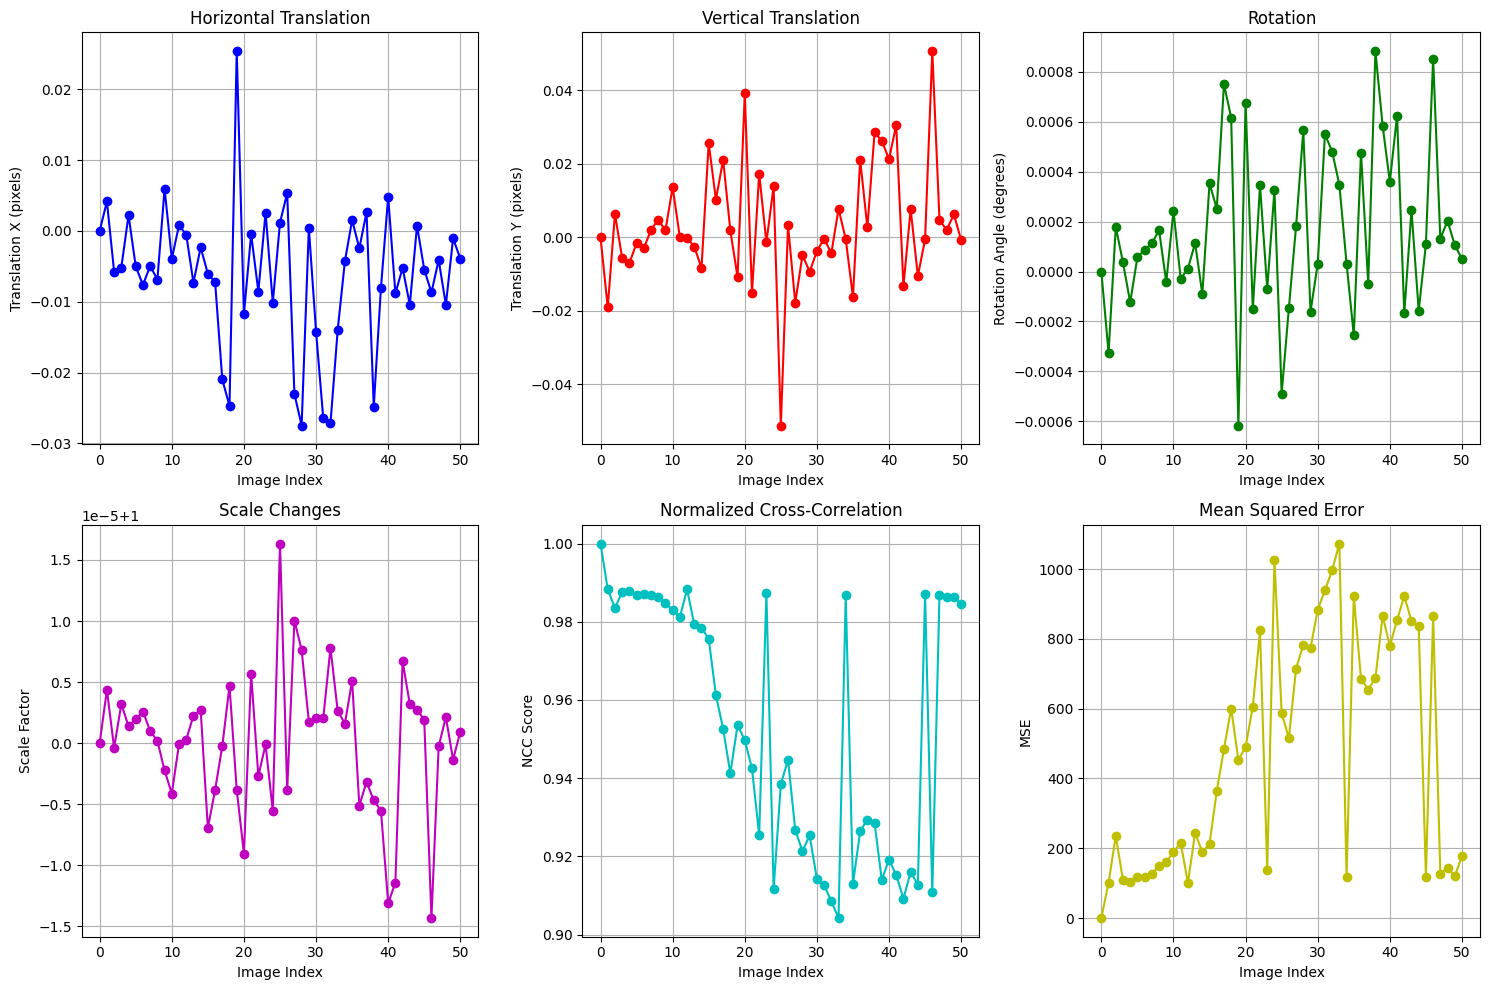

REGISTRATION ANALYSIS SUMMARY
Maximum Translation X: 0.03 pixels
Maximum Translation Y: 0.05 pixels
Maximum Rotation: 0.00 degrees
Scale Variation: 0.0000 (std dev)
Average NCC: 0.9529
Average MSE: 477.42

REGISTRATION TYPE RECOMMENDATION

Based on analysis, your images require:
• **Minimal registration needed** - simple rigid/translation may suffice

----------------------------------------
SUGGESTED REGISTRATION ALGORITHMS:
----------------------------------------
Use **Phase Correlation** or **Feature-based Registration**

Consider these approaches:
1. Feature-based: SIFT, ORB, AKAZE
2. Intensity-based: Phase correlation, cross-correlation
3. For laser-matter: Pay attention to plasma region features


In [6]:
def main():
    # Update this path to your folder
    folder_path = "C:/Users/Sinjini/Documents/Semester 3/MLDM Project/Real_Images"
    
    print("Loading image sequence...")
    images, filenames = load_image_sequence(folder_path)
    print(f"Loaded {len(images)} images")
    
    # Quick visual check
    print("\nPerforming visual assessment...")
    quick_visual_assessment(images)
    
    # Comprehensive analysis
    print("\nAnalyzing registration requirements...")
    df = analyze_registration_issues(images)
    
    # Visualize results
    visualize_transformations(df)
    
    # Determine registration type needed
    determine_registration_type(df)
    
    return df

def determine_registration_type(df):
    """Recommend registration type based on analysis"""
    print("\n" + "=" * 60)
    print("REGISTRATION TYPE RECOMMENDATION")
    print("=" * 60)
    
    max_trans_x = df['translation_x'].abs().max()
    max_trans_y = df['translation_y'].abs().max()
    max_rotation = df['rotation_angle'].abs().max()
    scale_std = df['scale_change'].std()
    
    recommendations = []
    
    if max_trans_x > 5 or max_trans_y > 5:
        recommendations.append("• **Translation correction needed** (significant shift detected)")
    
    if max_rotation > 2:
        recommendations.append("• **Rotational correction needed**")
    
    if scale_std > 0.05:
        recommendations.append("• **Scale correction needed** (affine transformation required)")
    
    if df['ncc_score'].mean() < 0.7:
        recommendations.append("• **Intensity normalization may be required**")
    
    if not recommendations:
        recommendations.append("• **Minimal registration needed** - simple rigid/translation may suffice")
    
    print("\nBased on analysis, your images require:")
    for rec in recommendations:
        print(rec)
    
    # Specific algorithm recommendation
    print("\n" + "-" * 40)
    print("SUGGESTED REGISTRATION ALGORITHMS:")
    print("-" * 40)
    
    if max_rotation > 5 or scale_std > 0.1:
        print("Use **Affine Registration** (cv2.estimateAffinePartial2D or SimpleITK.AffineTransform)")
    elif max_trans_x > 10 or max_trans_y > 10:
        print("Use **Rigid Registration** (translation + rotation)")
    else:
        print("Use **Phase Correlation** or **Feature-based Registration**")
    
    print("\nConsider these approaches:")
    print("1. Feature-based: SIFT, ORB, AKAZE")
    print("2. Intensity-based: Phase correlation, cross-correlation")
    print("3. For laser-matter: Pay attention to plasma region features")

if __name__ == "__main__":
    df_results = main()